In [15]:
!pip install dicom2nifti torchio --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.2/196.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 21.1 MB/s eta 0:00:00:00:0100:01


### Import Libraries

In [16]:
from huggingface_hub import login
# from kaggle_secrets import UserSecretsClient # Comment out this line if not running in Kaggle
import dicom2nifti
import zipfile
import os
from dotenv import load_dotenv
import torchio as tio
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

**If You Use Kaggle to Store Secrets**

In [5]:
# Comment out this cell if not running in Kaggle.

load_dotenv()
hf_token = os.environ.get("huggingface_token")
# user_secrets = UserSecretsClient()
# hf_token = user_secrets.get_secret("huggingface_token")
login(hf_token)

### Download Dataset

In [6]:
from huggingface_hub import hf_hub_download

filepath = hf_hub_download(
    repo_id="deeplearningresearchproject/dataset_project",
    filename="LIDC-IDRI-0050.zip",
    repo_type="dataset"
)

print(filepath)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


LIDC-IDRI-0050.zip:   0%|          | 0.00/2.80G [00:00<?, ?B/s]

/root/.cache/huggingface/hub/datasets--deeplearningresearchproject--dataset_project/snapshots/feef574cf9243e5c8692fb6dbf18ac61e780d72a/LIDC-IDRI-0050.zip


### DICOM to NIfTI Conversion

In [7]:
class Niftify:

    def __init__(self, zip_path, extract_to, nifti_path):
        self.zip_path = zip_path
        self.extract_to = extract_to
        self.nifti_path = nifti_path
        
    def unzip_file(self):
        """
        Unzips a ZIP file to the specified directory.
    
        :param zip_path: Path to the .zip file
        :param extract_to: Directory where files will be extracted
        """
        try:
            if not os.path.isfile(self.zip_path):
                raise FileNotFoundError(f"ZIP file not found: {self.zip_path}")
    
            os.makedirs(self.extract_to, exist_ok=True)
    
            # Open and extract the ZIP file
            with zipfile.ZipFile(self.zip_path, 'r') as zip_ref:
                zip_ref.extractall(self.extract_to)
                print(f"Extracted {len(zip_ref.namelist())} files to '{self.extract_to}'")
    
        except zipfile.BadZipFile:
            print("Error: The file is not a valid ZIP archive.")
        except PermissionError:
            print("Error: Permission denied while accessing files.")
        except Exception as e:
            print(f"An unexpected error occurred: {e}")

    def to_nifti(self):
        assert os.path.isdir(self.extract_to), f"{self.extract_to} is not a directory"
        
        os.makedirs(self.nifti_path, exist_ok=True)
        dicom2nifti.convert_directory(self.extract_to, self.nifti_path)

    def run(self):
        self.unzip_file()
        self.to_nifti()


### Run Conversion

In [8]:
dicom_path = './dicom'
nifti_path = './nifti'
niftify = Niftify(filepath, dicom_path, nifti_path)
niftify.run()

Extracted 9142 files to './dicom'


### List Dataset Files

In [ ]:
dataset= os.listdir(nifti_path)

## Visualization


File: 3000611.nii.gz
Volume shape: (512, 512, 140)
Voxel size: (np.float32(0.820312), np.float32(0.820312), np.float32(2.5))
Data type: float64
Intensity range: [-2048.00, 5892.00]


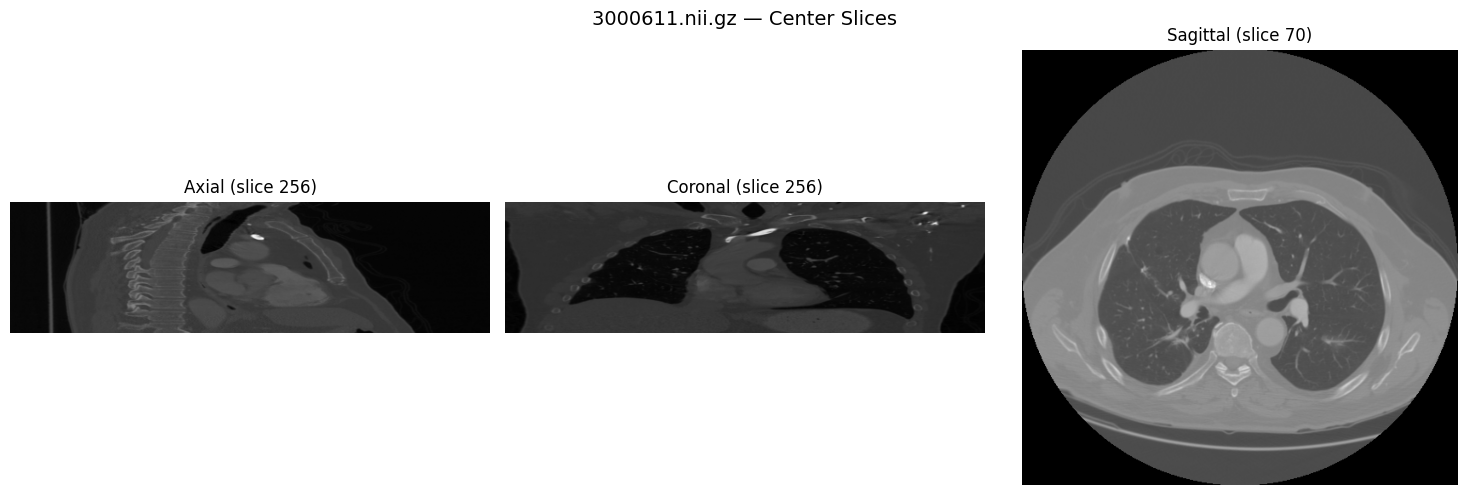

In [25]:

# Load the first NIfTI file
nifti_file = os.path.join(nifti_path, dataset[1])
img = nib.load(nifti_file)
volume = img.get_fdata()

print(f"File: {dataset[1]}")
print(f"Volume shape: {volume.shape}")
print(f"Voxel size: {img.header.get_zooms()}")
print(f"Data type: {volume.dtype}")
print(f"Intensity range: [{volume.min():.2f}, {volume.max():.2f}]")

# Show slices along all 3 axes at the center of the volume
mid = [s // 2 for s in volume.shape]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(volume[mid[0], :, :].T, cmap='gray', origin='lower')
axes[0].set_title(f'Axial (slice {mid[0]})')
axes[0].axis('off')

axes[1].imshow(volume[:, mid[1], :].T, cmap='gray', origin='lower')
axes[1].set_title(f'Coronal (slice {mid[1]})')
axes[1].axis('off')

axes[2].imshow(volume[:, :, mid[2]].T, cmap='gray', origin='lower')
axes[2].set_title(f'Sagittal (slice {mid[2]})')
axes[2].axis('off')

plt.suptitle(f'{dataset[1]} — Center Slices', fontsize=14)
plt.tight_layout()
plt.show()



### Axial Montage

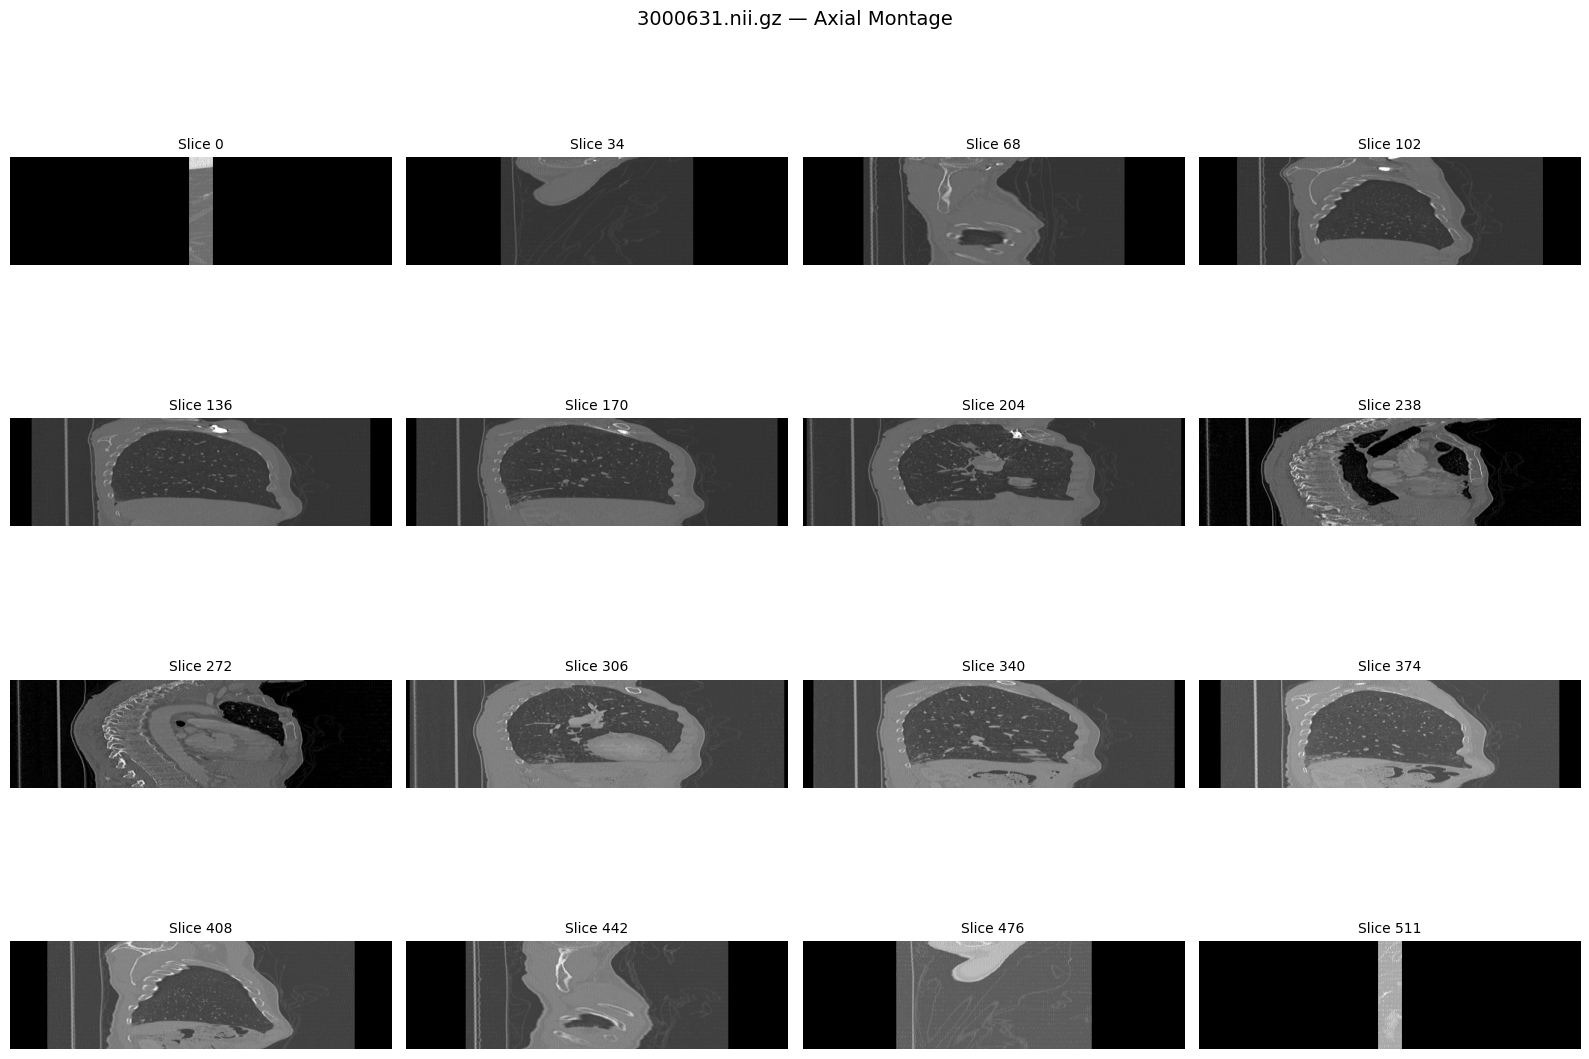

In [18]:
# Montage: evenly spaced axial slices
n_slices = 16
indices = np.linspace(0, volume.shape[0] - 1, n_slices, dtype=int)
cols = 4
rows = n_slices // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
for i, idx in enumerate(indices):
    ax = axes[i // cols, i % cols]
    ax.imshow(volume[idx, :, :].T, cmap='gray', origin='lower')
    ax.set_title(f'Slice {idx}', fontsize=10)
    ax.axis('off')

plt.suptitle(f'{dataset[0]} — Axial Montage', fontsize=14)
plt.tight_layout()
plt.show()



### Intensity Histogram

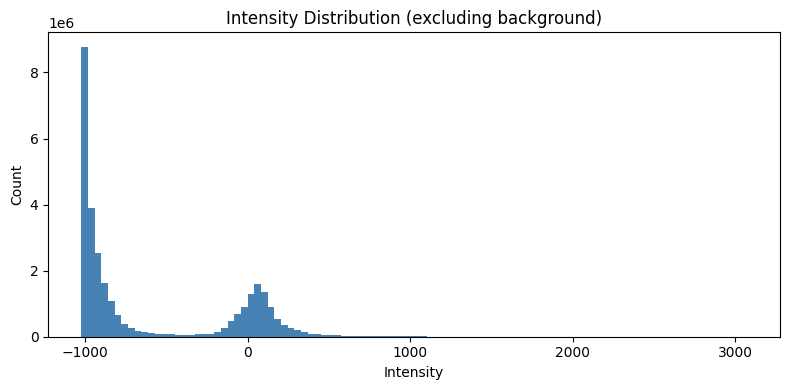

In [19]:
# Intensity histogram
fig, ax = plt.subplots(figsize=(8, 4))
flat = volume.flatten()
flat = flat[flat > flat.min()]  # exclude background
ax.hist(flat, bins=100, color='steelblue', edgecolor='none')
ax.set_xlabel('Intensity')
ax.set_ylabel('Count')
ax.set_title('Intensity Distribution (excluding background)')
plt.tight_layout()
plt.show()

## Preprocessing Pipeline (Resample → Crop/Pad → Normalize)


In [36]:
# Define the preprocessing pipeline in correct order:
# 1. Isotropic resampling  2. Crop/Pad  3. Intensity normalization
target_shape = (256, 256, 128)
processed_dir = './processed'
os.makedirs(processed_dir, exist_ok=True)

pipeline = tio.Compose([
    tio.Resample(1.0),
    tio.CropOrPad(target_shape),
    tio.RescaleIntensity(out_min_max=(0, 1)),
])

# Apply pipeline to ALL subjects, saving results to disk
for i, fname in enumerate(dataset):
    fpath = os.path.join(nifti_path, fname)
    out_path = os.path.join(processed_dir, fname)
    subj = tio.Subject(chest_ct=tio.ScalarImage(fpath))
    print(f"[{i+1}/{len(dataset)}] {fname}:", flush=True)
    print(f"  Original  → shape={subj.chest_ct.shape}, spacing={tuple(round(s,2) for s in subj.chest_ct.spacing)}, range=[{subj.chest_ct.data.min():.0f}, {subj.chest_ct.data.max():.0f}]", flush=True)
    trans = pipeline(subj)
    trans.chest_ct.save(out_path)
    print(f"  Processed → shape={trans.chest_ct.shape}, spacing={tuple(round(s,2) for s in trans.chest_ct.spacing)}, range=[{trans.chest_ct.data.min():.2f}, {trans.chest_ct.data.max():.2f}]", flush=True)
    del subj, trans  # free memory

print(f"\nSaved {len(dataset)} processed subjects to '{processed_dir}'")

[1/50] 3000631.nii.gz:
  Original  → shape=(1, 512, 512, 145), spacing=(0.78, 0.78, 2.5), range=[-2048, 3071]
  Processed → shape=(1, 256, 256, 128), spacing=(1.0, 1.0, 1.0), range=[0.00, 1.00]
[2/50] 3000611.nii.gz:


KeyboardInterrupt: 

### Preprocessed Sample Visualization

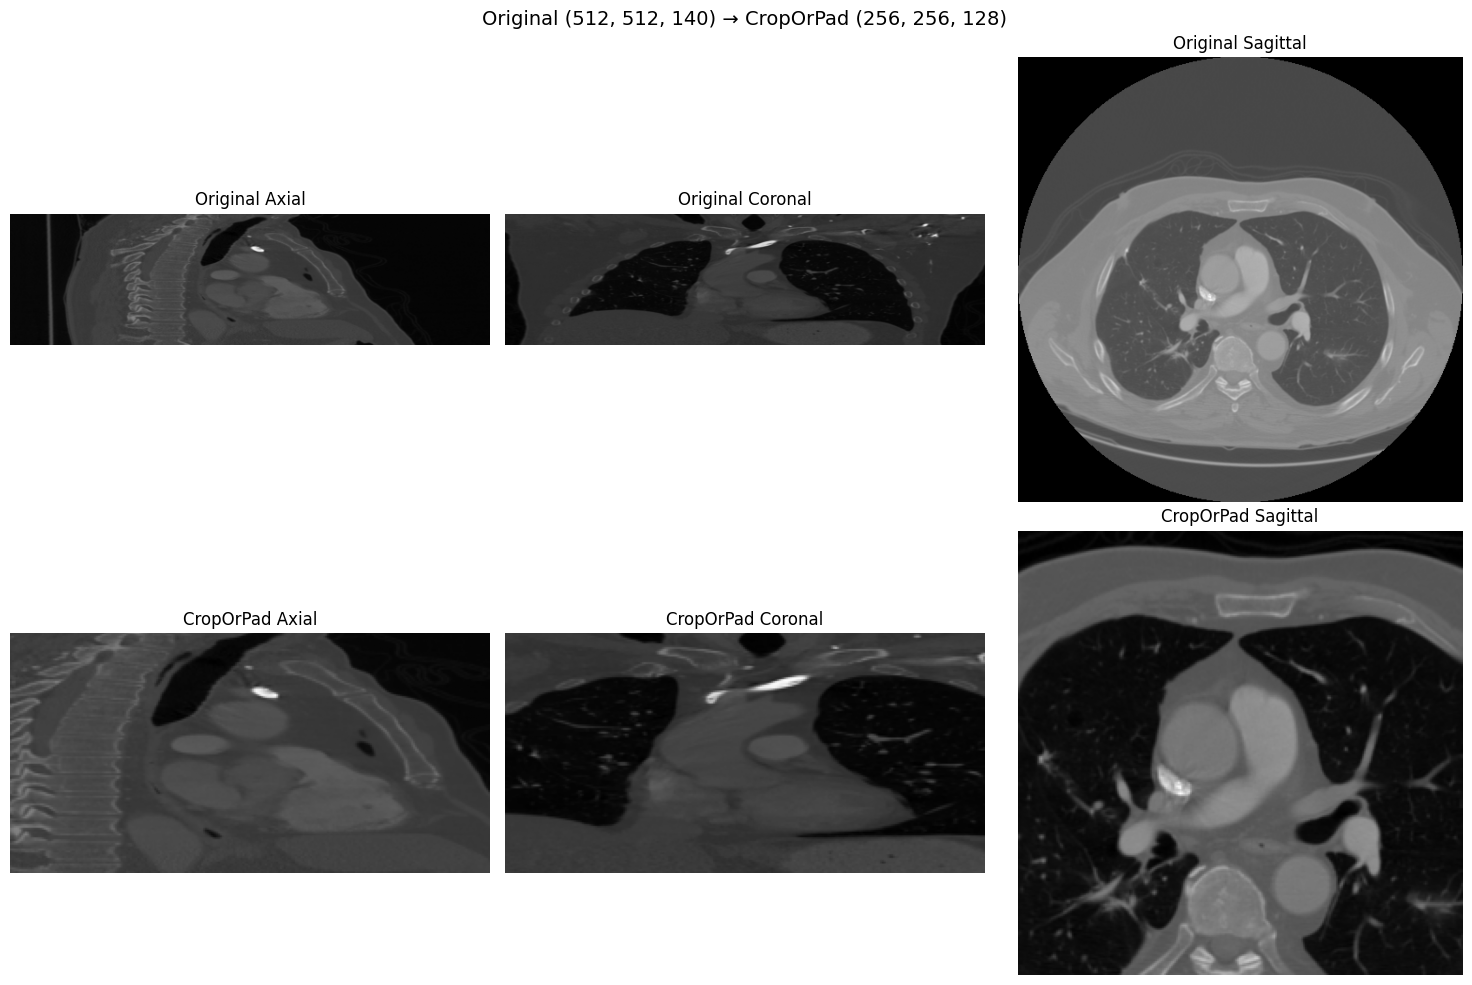

In [ ]:
# Visualize one sample: original vs fully preprocessed
sample_fname = dataset[0]
orig_subj = tio.Subject(chest_ct=tio.ScalarImage(os.path.join(nifti_path, sample_fname)))
trans_subj = tio.Subject(chest_ct=tio.ScalarImage(os.path.join(processed_dir, sample_fname)))

orig_vol = orig_subj.chest_ct.data.squeeze().numpy()
trans_vol = trans_subj.chest_ct.data.squeeze().numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

orig_mid = [s // 2 for s in orig_vol.shape]
trans_mid = [s // 2 for s in trans_vol.shape]

for col, axis_name in enumerate(['Axial', 'Coronal', 'Sagittal']):
    if col == 0:
        orig_slice = orig_vol[orig_mid[0], :, :].T
        trans_slice = trans_vol[trans_mid[0], :, :].T
    elif col == 1:
        orig_slice = orig_vol[:, orig_mid[1], :].T
        trans_slice = trans_vol[:, trans_mid[1], :].T
    else:
        orig_slice = orig_vol[:, :, orig_mid[2]].T
        trans_slice = trans_vol[:, :, trans_mid[2]].T

    axes[0, col].imshow(orig_slice, cmap='gray', origin='lower')
    axes[0, col].set_title(f'Original {axis_name}\nspacing={tuple(round(s,2) for s in orig_subj.chest_ct.spacing)}')
    axes[0, col].axis('off')

    axes[1, col].imshow(trans_slice, cmap='gray', origin='lower', vmin=0, vmax=1)
    axes[1, col].set_title(f'Processed {axis_name}\nspacing={tuple(round(s,2) for s in trans_subj.chest_ct.spacing)}')
    axes[1, col].axis('off')

plt.suptitle(f'{sample_fname}: Original {orig_vol.shape} → Processed {trans_vol.shape}', fontsize=14)
plt.tight_layout()
plt.show()

# Intensity histograms comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

orig_flat = orig_vol.flatten()
orig_flat = orig_flat[orig_flat > orig_flat.min()]
axes[0].hist(orig_flat, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Original Intensity Distribution')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Count')

trans_flat = trans_vol.flatten()
trans_flat = trans_flat[trans_flat > trans_flat.min()]
axes[1].hist(trans_flat, bins=100, color='coral', edgecolor='none')
axes[1].set_title('Processed Intensity Distribution [0, 1]')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()